### Import python packages

In [1]:
import numpy as np
import pandas as pd
import os 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt   
from matplotlib.pyplot import cm
from pyDGSA.cluster import KMedoids
from pyDGSA.dgsa import dgsa
import parameter_dist

c:\Users\homme\Desktop\Python\TCE_UQ\parameter_dist.py:427: SyntaxWarning: invalid escape sequence '\m'
  '''
c:\Users\homme\Desktop\Python\TCE_UQ\parameter_dist.py:728: SyntaxWarning: invalid escape sequence '\m'
  '''


### Call the input set

In [2]:
# Create a dictionary with all the series
data_dict = {
    "x1": parameter_dist.log10_dissolution_rate_FeS['parameters'],
    "x2": parameter_dist.log10_dissolution_rate_pyrite['parameters'],
    "x3": parameter_dist.log10_dissolution_rate_siderite['parameters'],
    
    "x5": parameter_dist.log10_dissolution_rate_goethite['parameters'],
    "x6": parameter_dist.log10_dissolution_rate_SOM['parameters'],
    "x7": parameter_dist.log10_equilibrium_constant_FeS['parameters'],
    "x8": parameter_dist.log10_equilibrium_constant_goethite['parameters'],
    "x9": parameter_dist.log10_rate_constant_goethite_dirb['parameters'],
    "x10": parameter_dist.log10_rate_constant_abiotic_fe_reduction['parameters'],
    "x11": parameter_dist.log10_rate_constant_sulfate_reduction['parameters'],
    "x12": parameter_dist.sorption_site_density_illite_str['parameters'],
    "x13": parameter_dist.sorption_site_density_illite_w['parameters'],
    "x14": parameter_dist.sorption_site_density_goethite['parameters'],
    "x15": parameter_dist.half_saturation_constant_sulfate['parameters'],
    "x16": parameter_dist.half_saturation_constant_acetate['parameters'],
    "x17": parameter_dist.inhibition_constant_Fe3['parameters'],
    "x18": parameter_dist.logit_initial_mineral_fraction_goethite['parameters'],
    "x19": parameter_dist.logit_initial_mineral_fraction_SOM['parameters'],
    "x20": parameter_dist.logit_initial_mineral_fraction_FeS['parameters'],
    "x21": parameter_dist.logit_initial_mineral_fraction_pyrite['parameters'],
    "x22": parameter_dist.logit_initial_mineral_fraction_siderite['parameters'],
    "x23": parameter_dist.logit_initial_mineral_fraction_illite['parameters'],
    "x24": parameter_dist.log_ssa_FeS['parameters'],
    "x25": parameter_dist.log_ssa_pyrite['parameters'],
    "x26": parameter_dist.log_ssa_siderite['parameters'],
    
    "x28": parameter_dist.log_tce_intrinsic_rate_constant_FeS['parameters'],
    "x29": parameter_dist.log_tce_intrinsic_rate_constant_pyrite['parameters'],
    "x30": parameter_dist.log_tce_intrinsic_rate_constant_siderite['parameters'],
    
    "x32": parameter_dist.groundwater_concentration_acetate['parameters'],
    "x33": parameter_dist.groundwater_concentration_sulfate['parameters'],
    "x34": parameter_dist.groundwater_concentration_Fe2['parameters'],
    "x35": parameter_dist.initial_concentration_Fe2['parameters'],
    "x36": parameter_dist.initial_concentration_pH['parameters'],
}

# Merge into a single DataFrame
merged_df = pd.DataFrame(data_dict)

# Check the shape to confirm (should be 2387 rows × 36 columns)
merged_df


param=merged_df.values[:,:]


In [3]:
param

array([[-8.85884720e+00, -1.25245792e+01, -1.16069693e+01, ...,
         1.01000000e-05,  4.24000000e-06,  7.58695454e+00],
       [-7.79649908e+00, -1.49498261e+01, -1.14494412e+01, ...,
         3.65000000e-05,  4.01000000e-06,  8.04305968e+00],
       [-6.00152759e+00, -1.72778588e+01, -8.87698418e+00, ...,
         3.96000000e-06,  2.55000000e-05,  7.88872096e+00],
       ...,
       [-1.04582805e+01, -1.72998769e+01, -1.00332131e+01, ...,
         2.04000000e-05,  3.01000000e-06,  7.78771560e+00],
       [-7.12294362e+00, -1.63791288e+01, -9.11989067e+00, ...,
         2.87000000e-05,  6.41000000e-05,  7.81439946e+00],
       [-9.69382939e+00, -1.14182568e+01, -8.56729770e+00, ...,
         4.78000000e-06,  6.98000000e-06,  7.69150620e+00]],
      shape=(4948, 33))

### Calculate the euclidean distances between model responses for each quantity of interest

In [ ]:

from scipy.spatial.distance import pdist, squareform

responses = 1-np.array(parameter_dist.tce_flux_reduction['valid_outputs_pd'])
responses_averageFeS = np.array(parameter_dist.average_mineral_content_change_FeS['valid_outputs_pd']) 
responses_averagepyrite = np.array(parameter_dist.average_mineral_content_change_pyrite['valid_outputs_pd']) 
responses_averagesiderite = np.array(parameter_dist.average_mineral_content_change_siderite['valid_outputs_pd'])
response_k_ratio = parameter_dist.k_fit_eff_ratio

response_new_volume_FeS_DGSA= parameter_dist.new_volume_FeS_DGSA
response_new_volume_pyrite_DGSA= parameter_dist.new_volume_pyrite_DGSA
response_new_volume_siderite_DGSA= parameter_dist.new_volume_siderite_DGSA

responses= responses.reshape(-1, 1)
responses_averageFeS = responses_averageFeS.reshape(-1, 1)
responses_averagepyrite = responses_averagepyrite.reshape(-1, 1)
responses_averagesiderite = responses_averagesiderite.reshape(-1, 1)

distances = pdist(responses, metric='euclidean')
distances_averageFeS  = pdist(responses_averageFeS , metric='euclidean')
distances_averagepyrite = pdist(responses_averagepyrite, metric = 'euclidean')
distances_averagesiderite = pdist(responses_averagesiderite, metric = 'euclidean')
distances_k_ratio = pdist(response_k_ratio, metric = 'euclidean')
distance_new_volume_FeS = pdist(response_new_volume_FeS_DGSA, metric = 'euclidean')
distance_new_volume_pyrite = pdist(response_new_volume_pyrite_DGSA, metric = 'euclidean')
distance_new_volume_siderite = pdist(response_new_volume_siderite_DGSA, metric = 'euclidean')


distances = squareform(distances)
distances_averageFeS = squareform(distances_averageFeS)
distances_averagepyrite = squareform(distances_averagepyrite)
distances_averagesiderite = squareform(distances_averagesiderite)
distances_k_ratio = squareform(distances_k_ratio)
distance_new_volume_FeS = squareform(distance_new_volume_FeS)
distance_new_volume_pyrite = squareform(distance_new_volume_pyrite)
distance_new_volume_siderite = squareform(distance_new_volume_siderite)

In [5]:
responses
responses_averageFeS
responses_averagepyrite
responses_averagesiderite
response_k_ratio
response_new_volume_FeS_DGSA


array([[6.65656357e+01],
       [4.79595320e-02],
       [6.27830396e+01],
       ...,
       [2.23443360e+01],
       [6.06091684e+01],
       [5.21458167e+01]], shape=(4943, 1))

### Clustering of the quantity of interest

In [6]:
from pyDGSA.cluster import KMedoids

n_clusters = 3
clusterer = KMedoids(n_clusters=n_clusters, max_iter=3000, tol=1e-4)
labels, medoids = clusterer.fit_predict(distances)


In [7]:
unique_labels, counts = np.unique(labels, return_counts=True)

# Display results
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} points")

Cluster 0: 3709 points
Cluster 1: 835 points
Cluster 2: 404 points


### Remap the cluster order (Cluster 0: Low, Cluster 1: Medium, Cluster 2: High)

In [8]:
unique_labels = np.unique(labels)

average_output_per_cluster = {
    label: responses[labels == label].mean() 
    for label in unique_labels
}

# ---- Print results ----
for label, avg_output in average_output_per_cluster.items():
    print(f"Cluster {label}: Average Output = {avg_output:.3f}")


mapping = {0: 0, 1: 1, 2: 2} #021  #201
new_labels = np.vectorize(mapping.get)(labels)
unique_labelss = np.unique(new_labels)


Cluster 0: Average Output = 0.025
Cluster 1: Average Output = 0.219
Cluster 2: Average Output = 0.607


In [9]:
for label in unique_labelss:
    cluster_values = responses[new_labels  == label].flatten()
    cluster_min = cluster_values.min()
    cluster_max = cluster_values.max()
    print(f"Cluster {label}: Min = {cluster_min:.3f}, Max = {cluster_max:.3f}")

Cluster 0: Min = 0.000, Max = 0.108
Cluster 1: Min = 0.108, Max = 0.411
Cluster 2: Min = 0.412, Max = 0.936


In [10]:
unique_labels, counts = np.unique(new_labels, return_counts=True)

# Display results
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} points")

Cluster 0: 3709 points
Cluster 1: 835 points
Cluster 2: 404 points


### Compute sensitivity using DGSA package

In [11]:
from pyDGSA.dgsa import dgsa

param_list=['Dissolution/Precipitation Rate of Mackinawite','Dissolution/Precipitation Rate of Pyrite','Dissolution/Precipitation Rate of Siderite','Dissolution/Precipitation Rate of Goethite','Dissolution/Precipitation Rate of SOM','Equilibrium Constant for Mackinawite','Equilibrium Constant for Goethite','Microbial Iron Reduction Rate Constant','Abiotic Iron Reduction Rate Constant','Sulfate Reduction Rate Constant',r"Sorption Site Density for $> \mathrm{Ill}_{str}\mathrm{OH}$",r"Sorption Site Density for $> \mathrm{Ill}_{w}\mathrm{OH}$",'Sorption Site Density for >GFeOH','Half Saturation Rate Constant for Sulfate','Half Saturation Rate Constant for Acetate',r'Inhibition Constant for $\mathrm{Fe}^{3+}$','Initial Bulk Volume Fraction of Goethite','Initial Bulk Volume Fraction of SOM','Initial Bulk Volume Fraction of Mackinawite','Initial Bulk Volume Fraction of Pyrite','Initial Bulk Volume Fraction of Siderite','Initial Bulk Volume Fraction of Illite','Specific Surface Area of Mackinawite','Specific Surface Area of Pyrite','Specific Surface Area of Siderite','Intrinsic Rate Constant of Mackinawite with TCE','Intrinsic Rate Constant of Pyrite with TCE','Intrinsic Rate Constant of Siderite with TCE','Concentration of Acetate in Groundwater','Concentration of Sulfate in Groundwater',r'Concentration of $\mathrm{Fe}^{2+}$ in Groundwater',r'Concentration of $\mathrm{Fe}^{2+}$ in LPZ','Initial pH within LPZ']

mean_sensitivity = dgsa(param, new_labels, parameter_names=param_list, quantile=0.99, 
                        n_boots=5000, confidence=True)
print(mean_sensitivity)

  0%|          | 0/5000 [00:00<?, ?it/s]

                                                    sensitivity  confidence
Dissolution/Precipitation Rate of Mackinawite          0.563623    0.215226
Dissolution/Precipitation Rate of Pyrite               0.837088    0.351302
Dissolution/Precipitation Rate of Siderite             0.483139    0.198883
Dissolution/Precipitation Rate of Goethite             0.328257    0.131572
Dissolution/Precipitation Rate of SOM                  0.279002    0.128269
Equilibrium Constant for Mackinawite                   0.398347    0.161464
Equilibrium Constant for Goethite                      0.590416    0.250303
Microbial Iron Reduction Rate Constant                 0.607245    0.253558
Abiotic Iron Reduction Rate Constant                   0.498831    0.219101
Sulfate Reduction Rate Constant                        0.829127    0.339923
Sorption Site Density for $> \mathrm{Ill}_{str}...     0.386504    0.159182
Sorption Site Density for $> \mathrm{Ill}_{w}\m...     0.681802    0.289461
Sorption Sit

### Compute cluster-level sensitivity using DGSA package

In [ ]:
cluster_names = ['Low', 'Medium', 'High']

cluster_sensitivity = dgsa(param, new_labels, parameter_names=param_list, 
                           output='cluster_avg', cluster_names=cluster_names)
print(cluster_sensitivity)

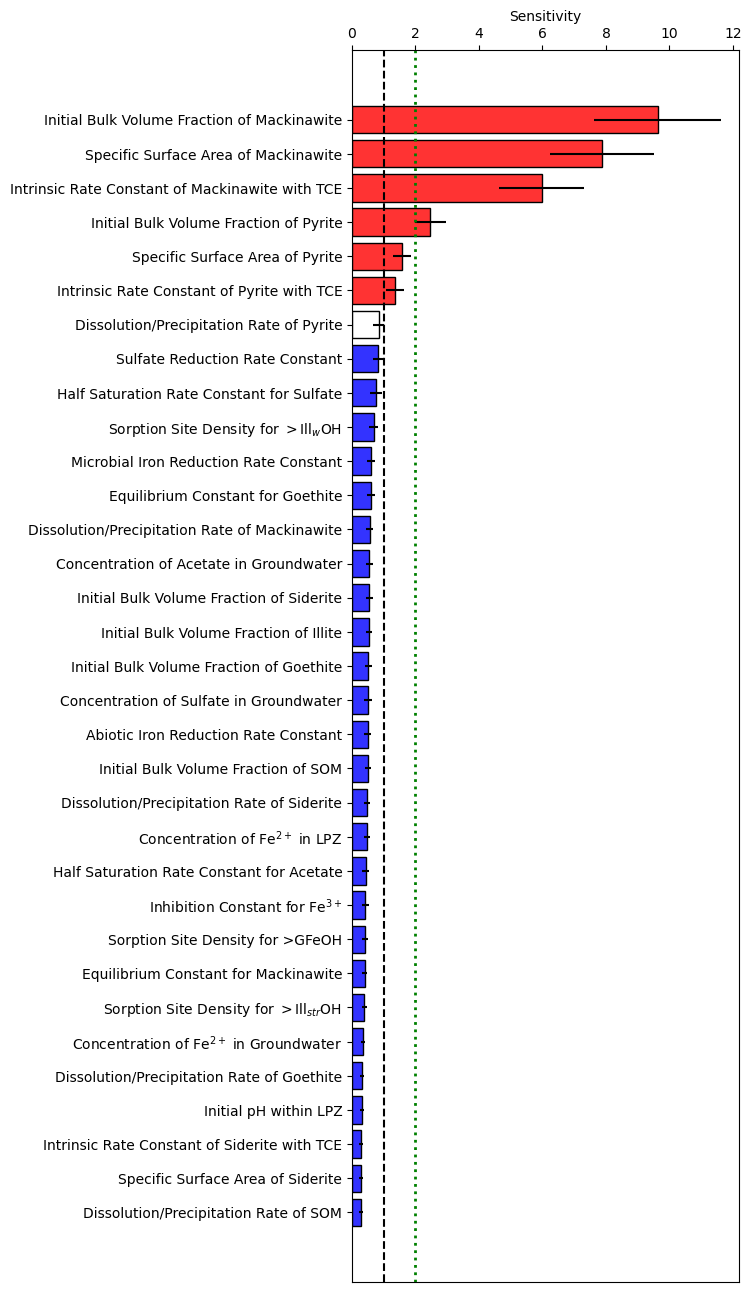

In [ ]:
from pyDGSA.plot import vert_pareto_plot

fig, ax = vert_pareto_plot(mean_sensitivity, np_plot='+31', confidence=True)
ax.axvline(x=2, color='green', linestyle=':', linewidth=2)
#fig.savefig("mainpareto_mackinawite.svg", format="svg", bbox_inches='tight')

In [ ]:
# Define the colors for each cluster
cluster_colors = ['green', 'yellow','orange']

# Only plot 3 parameters total to save space (np_plot=3)
fig, ax = vert_pareto_plot(cluster_sensitivity, np_plot=9, fmt='cluster_avg', 
                           colors=cluster_colors)

In [ ]:
from pyDGSA.plot import plot_cdf
from scipy.special import expit
#fig, ax = plot_cdf(expit(param), new_labels, 'Initial Bulk Volume Fraction of Pyrite', parameter_names=param_list, 
#                   cluster_names=cluster_names, colors=cluster_colors)

fig, ax = plot_cdf(param, new_labels, 'Microbial Iron Reduction Rate Constant', parameter_names=param_list, 
                   cluster_names=cluster_names, colors=cluster_colors)

ax.set_title('Microbial Iron Reduction Rate Constant', fontsize=16)
ax.set_xlabel(r'$\mathrm{log_{10}(mol/m^2/s)}$', fontsize=16)  # log $\mathrm{m^2/g}$  m3/m3  mol/m^2/s m^3/m^3  mol/m2/s  mol/L/yr  log_e logit(\phi) log_{10}
ax.set_ylabel(r'% of simulation', fontsize=16) 

# Tick labels
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend font size
ax.legend(fontsize=11)
#plt.xscale('log')
plt.tight_layout()
plt.show()

### Compute interaction sensitivity

In [ ]:
from pyDGSA.dgsa import dgsa_interactions
mean_interact_sensitivity = dgsa_interactions(param, new_labels, 
                                              parameter_names=param_list)





print(mean_interact_sensitivity)

In [ ]:
fig, ax = vert_pareto_plot(mean_interact_sensitivity, np_plot='+31')
ax.axvline(x=2, color='green', linestyle=':', linewidth=2)
fig.savefig("pareto_plot.svg", format="svg", bbox_inches='tight')

### Scatter plot for the values of the quantity of interest

In [ ]:
# Custom mapping: cluster ID → name
label_map = {0: "Low", 1: "Medium", 2: "High"}
# Custom colors for each cluster
cluster_colors = ['green', 'yellow', 'orange']



mapping = {0: 0, 1: 1, 2: 2}
new_labels = np.vectorize(mapping.get)(labels)
label_map = {0: "Low", 1: "Medium", 2: "High"}
unique_labels = np.unique(new_labels)

unique_labels
plt.figure()

for unique_labels in np.unique(new_labels):
    mask = labels == unique_labels
    lbl = mapping[unique_labels]
    plt.scatter(
        x[mask], response[mask],
        s=50, alpha=0.8,
        color=cluster_colors[lbl],   # use your custom color
        label=label_map[lbl]         # use your custom label
    )

# Optional: highlight medoids
# plt.scatter(medoids, response[medoids], c='red', marker='X', s=200, label='Medoids')

plt.xlabel("Realization number",fontsize = 16)
plt.ylabel(r'$\mathrm{k_{fit}/k_{eff}}$ ratio',fontsize = 15)  #Integrated siderite volume change   r'$\mathrm{k_{fit}/k_{eff}}$ ratio'
plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=16)
#plt.legend(fontsize = 11)
plt.ylim(0.001, 10000000)
plt.tight_layout()
plt.show()
